<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/miniProjecr2%20/%20MP2_Part3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Q3***

# ***part 1***

# **gdown installation**

In [ ]:
!pip install gdown

# **Use gdown to download pictures**

In [ ]:
import gdown

gdown.download('https://drive.google.com/uc?id=1Go32WFOXGSCMv27YYYqtKCReNuX3TdND', '1.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?id=1Z_3wtSRL6wIZ5Ar0whz5jsGxMLIios-6', '2.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?id=1c3OmUzexdg789Hr-eWO_6T-BVVugX43f', '3.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?id=1a9piRMakoR3ONrccG4-WKakt0Xt8DtX_', '4.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?id=1WpyQF_UZQnrAHeHvnouQ--84olNgOR0P', '5.jpg', quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1Go32WFOXGSCMv27YYYqtKCReNuX3TdND
To: /content/1.jpg
100%|██████████| 1.49k/1.49k [00:00<00:00, 3.76MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z_3wtSRL6wIZ5Ar0whz5jsGxMLIios-6
To: /content/2.jpg
100%|██████████| 1.65k/1.65k [00:00<00:00, 4.01MB/s]
Downloading...
From: https://drive.google.com/uc?id=1c3OmUzexdg789Hr-eWO_6T-BVVugX43f
To: /content/3.jpg
100%|██████████| 1.90k/1.90k [00:00<00:00, 3.25MB/s]
Downloading...
From: https://drive.google.com/uc?id=1a9piRMakoR3ONrccG4-WKakt0Xt8DtX_
To: /content/4.jpg
100%|██████████| 1.50k/1.50k [00:00<00:00, 5.11MB/s]
Downloading...
From: https://drive.google.com/uc?id=1WpyQF_UZQnrAHeHvnouQ--84olNgOR0P
To: /content/5.jpg
100%|██████████| 1.47k/1.47k [00:00<00:00, 3.31MB/s]


'5.jpg'

# **Convert image to binary vector**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def image_to_binary_array(filename):
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (6, 6))
    _, binary = cv2.threshold(img, 128, 1, cv2.THRESH_BINARY_INV)
    return binary.flatten()


# **Load and prepare training data**

In [ ]:
letter_images = []
for i in range(1, 6):
    vector = image_to_binary_array(f'{i}.jpg')
    letter_images.append(vector)


train_data = np.array(letter_images)

# Labels for the Persian letters
letter_labels = ['آ' , 'ب' , 'ج' , 'د' , 'و']

# **Add noise to input data**

In [ ]:
def add_noise(data, noise_level=0.3):
    noisy_data = data.copy()
    num_noise = int(noise_level * len(data))
    noise_indices = np.random.choice(len(data), num_noise, replace=False)
    noisy_data[noise_indices] = 1 - noisy_data[noise_indices]
    return noisy_data

# ***part 2***

# **Define Hamming Network**

In [ ]:
def hamming_network(input_data, train_data):
    num_samples = train_data.shape[0]
    input_norm = np.sum(input_data)
    similarities = []

    for i in range(num_samples):
        template = train_data[i]
        dot_product = np.dot(input_data, template)
        template_norm = np.sum(template)
        similarity = dot_product / (input_norm + template_norm - dot_product + 1e-6)  # Avoid division by zero
        similarities.append(similarity)

    best_match = np.argmax(similarities)
    return train_data[best_match], best_match

# **Test network with noisy input**

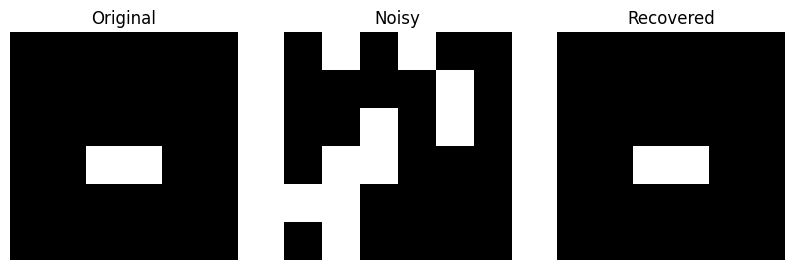

Detected Letter: ب


In [ ]:
true_index = 2
original = train_data[true_index]

# Add noise to the original input
noisy_input = add_noise(original, noise_level=0.3)

# Run Hamming network to recover the closest match
output, predicted_index = hamming_network(noisy_input, train_data)

# Show the original, noisy, and recovered images
def show_images(original, noisy, recovered):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    for ax, data, title in zip(axs, [original, noisy, recovered], ['Original', 'Noisy', 'Recovered']):
        ax.imshow(data.reshape(6, 6), cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.show()

# Display results
show_images(original, noisy_input, output)
print("Detected Letter:", letter_labels[predicted_index])

# **Test with multiple noise levels**

Noise: 10%, Predicted: ب


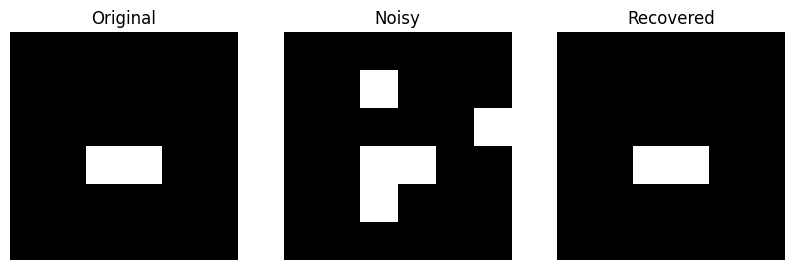

Noise: 30%, Predicted: ب


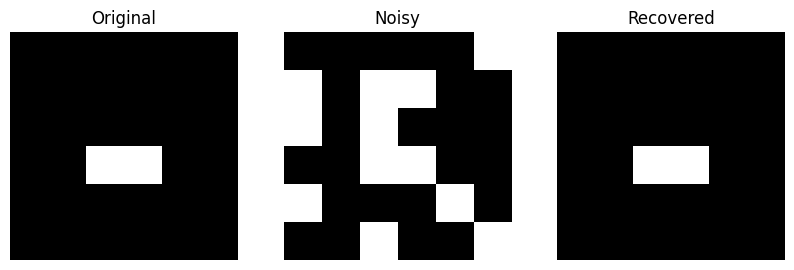

Noise: 50%, Predicted: آ


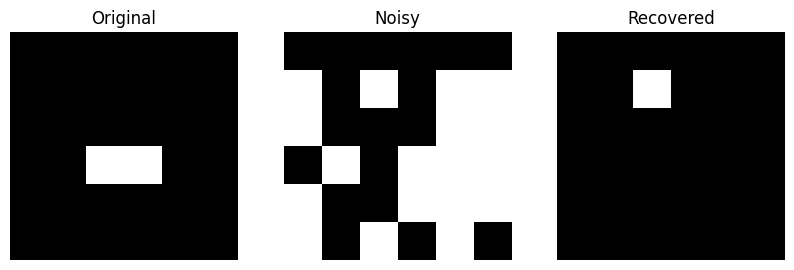

Noise: 70%, Predicted: آ


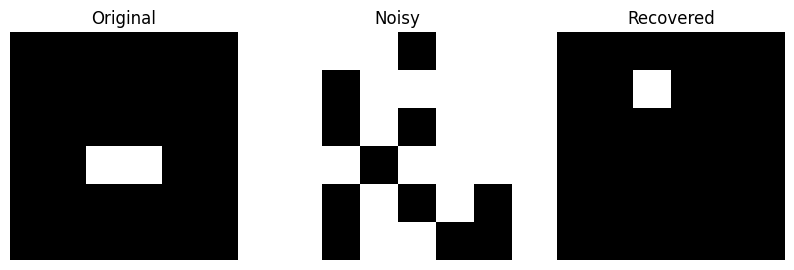

In [ ]:
# Test how the network works with different levels of noise
for noise in [0.1, 0.3, 0.5, 0.7]:
    noisy_input = add_noise(original, noise_level=noise)
    output, pred = hamming_network(noisy_input, train_data)
    print(f"Noise: {int(noise*100)}%, Predicted: {letter_labels[pred]}")
    show_images(original, noisy_input, output)

# ***part 3***

# **Add missing points (Simulate Lost Pixels)**

In [ ]:
# This function sets some values to 0 (simulate missing pixels)
def add_missing_points(data, missing_ratio=0.3):
    data_missing = data.copy()
    num_missing = int(missing_ratio * len(data))
    missing_indices = np.random.choice(len(data), num_missing, replace=False)
    data_missing[missing_indices] = 0
    return data_missing

# **Test with missing points**

Missing: 10%, Predicted: ب


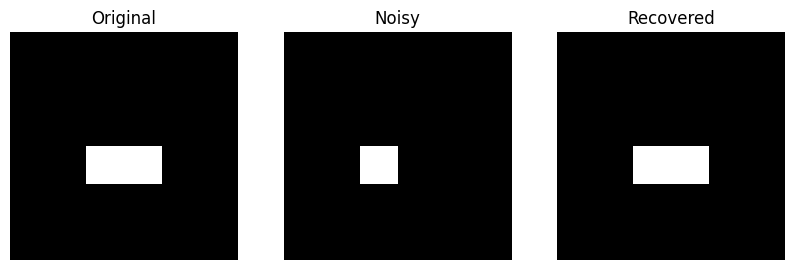

Missing: 30%, Predicted: ب


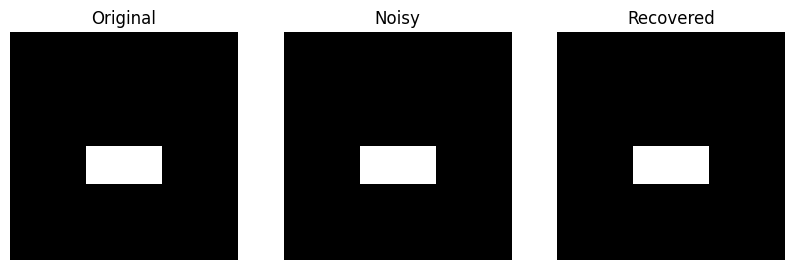

Missing: 50%, Predicted: ب


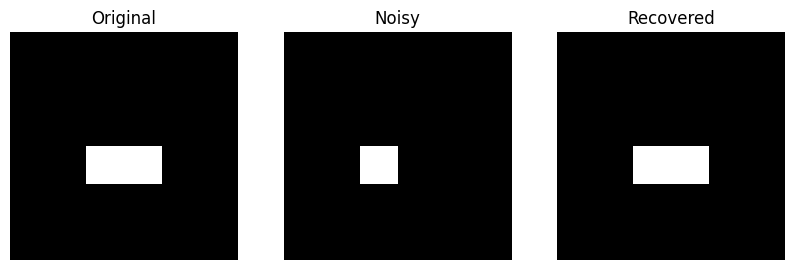

Missing: 70%, Predicted: آ


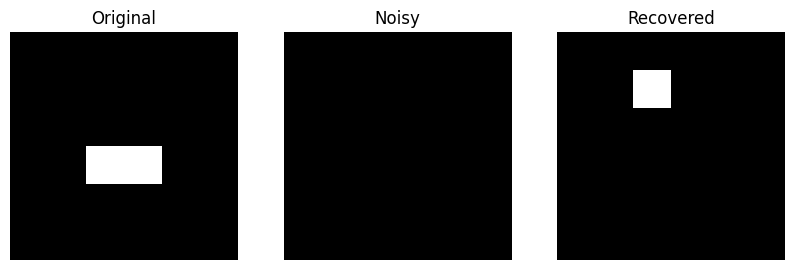

In [ ]:
# Test how the network works with missing pixels
for miss in [0.1, 0.3, 0.5, 0.7]:
    missing_input = add_missing_points(original, missing_ratio=miss)
    output, pred = hamming_network(missing_input, train_data)
    print(f"Missing: {int(miss*100)}%, Predicted: {letter_labels[pred]}")
    show_images(original, missing_input, output)

# ***Q4***

# ***part 1***

# **Define weights and inputs (for the original neural network with one hidden layer)**

In [ ]:
# Inputs
x1 = 1
x2 = 2

# Weights (random values for example)
w1 = 0.1
w2 = 0.2
w3 = 0.3
w4 = 0.4
w5 = 0.5
w6 = 0.6
w7 = 0.7
w8 = 0.8
w9 = 0.9

# Constant for linear activation
c = 1

# **Compute values in the hidden layer and output layer**

In [ ]:
# Compute z1 and z2 (inputs to hidden neurons)
z1 = w1 + w3 * x1 + w5 * x2
z2 = w2 + w4 * x1 + w6 * x2

# Apply linear activation h(z) = c * z
h1 = c * z1
h2 = c * z2

# Compute input to output neuron
z_output = w7 + w8 * h1 + w9 * h2


output = 1 / (1 + pow(2.71828, -z_output))


print("P(y = 1 | x, w) =", output)

P(y = 1 | x, w) = 0.9999999995400879


# ***part 2***

# **Define inputs and original weights**

In [ ]:
# Inputs
x1 = 1
x2 = 2

# Original weights
w1 = 0.1
w2 = 0.2
w3 = 0.3
w4 = 0.4
w5 = 0.5
w6 = 0.6
w7 = 0.7
w8 = 0.8
w9 = 0.9

# Constant for linear activation
c = 1

# **Compute equivalent weights (no hidden layer)**

In [ ]:
# Compute new bias (w~0)
w0_new = w7 + c * w8 * w1 + c * w9 * w2

# Compute new weight for x1 (w~1)
w1_new = c * w8 * w3 + c * w9 * w4

# Compute new weight for x2 (w~2)
w2_new = c * w8 * w5 + c * w9 * w6

# **Compute output using new weights**

In [ ]:
# Compute final z using new weights
z_new = w0_new + w1_new * x1 + w2_new * x2

# Sigmoid output
output_new = 1 / (1 + pow(2.71828, -z_new))

print("P(Y = 1 | X, W) with NO hidden layer =", output_new)

P(Y = 1 | X, W) with NO hidden layer = 0.968931446183622
